## 🌊 IEA Wind Task 55

**Concepts:** [Warm-starting](../routers.md#warm-starting) **Reference:** [Input Formats](../reference/input_formats.md) **Network/Router API:** [🌊 IEA Wind Task 55](hi41_example_iea_wind_task_55.ipynb)

**IEA Wind TCP Task 55: The IEA Wind 740-10-MW Reference Offshore Wind Plants**

<https://www.osti.gov/biblio/2333634/>

This notebook uses `optiwindnet` to route the collection system cables for the two wind power plants presented in the report above.

In [1]:
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.converting import G_from_S
from optiwindnet.importer import L_from_windIO
from optiwindnet.interarraylib import assign_cables
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot
from optiwindnet.transforming import as_normalized

### Load layouts from files

In [2]:
L_reg = L_from_windIO('data/IEA37_Borssele_Regular_System.yaml')

In [3]:
L_irr = L_from_windIO('data/IEA37_Borssele_Irregular_System.yaml')

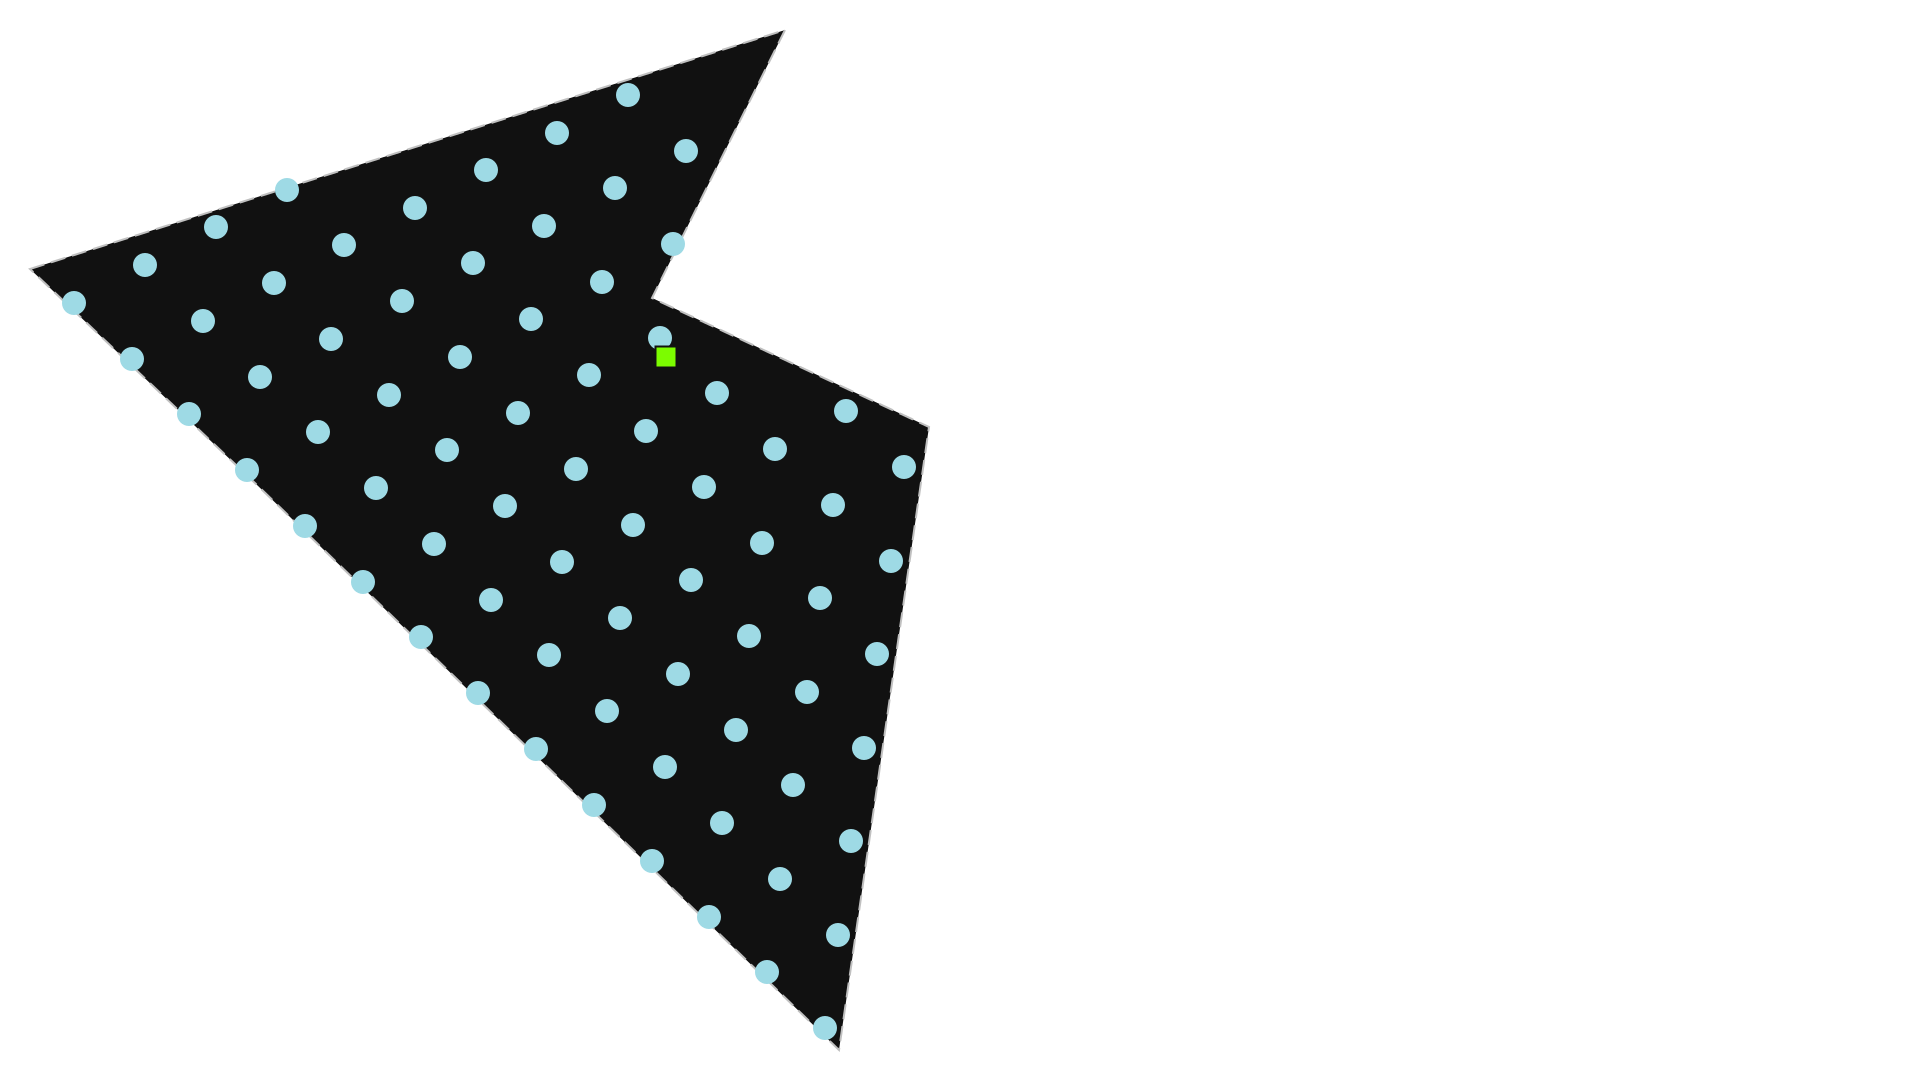

In [4]:
svgplot(L_reg)

In [5]:
L_reg.graph.keys()

dict_keys(['T', 'R', 'B', 'VertexC', 'name', 'handle', 'border'])

In [6]:
R, T, B, VertexC = (L_reg.graph[key] for key in ['R', 'T', 'B', 'VertexC'])

In [7]:
R, T, B

(1, 74, 6)

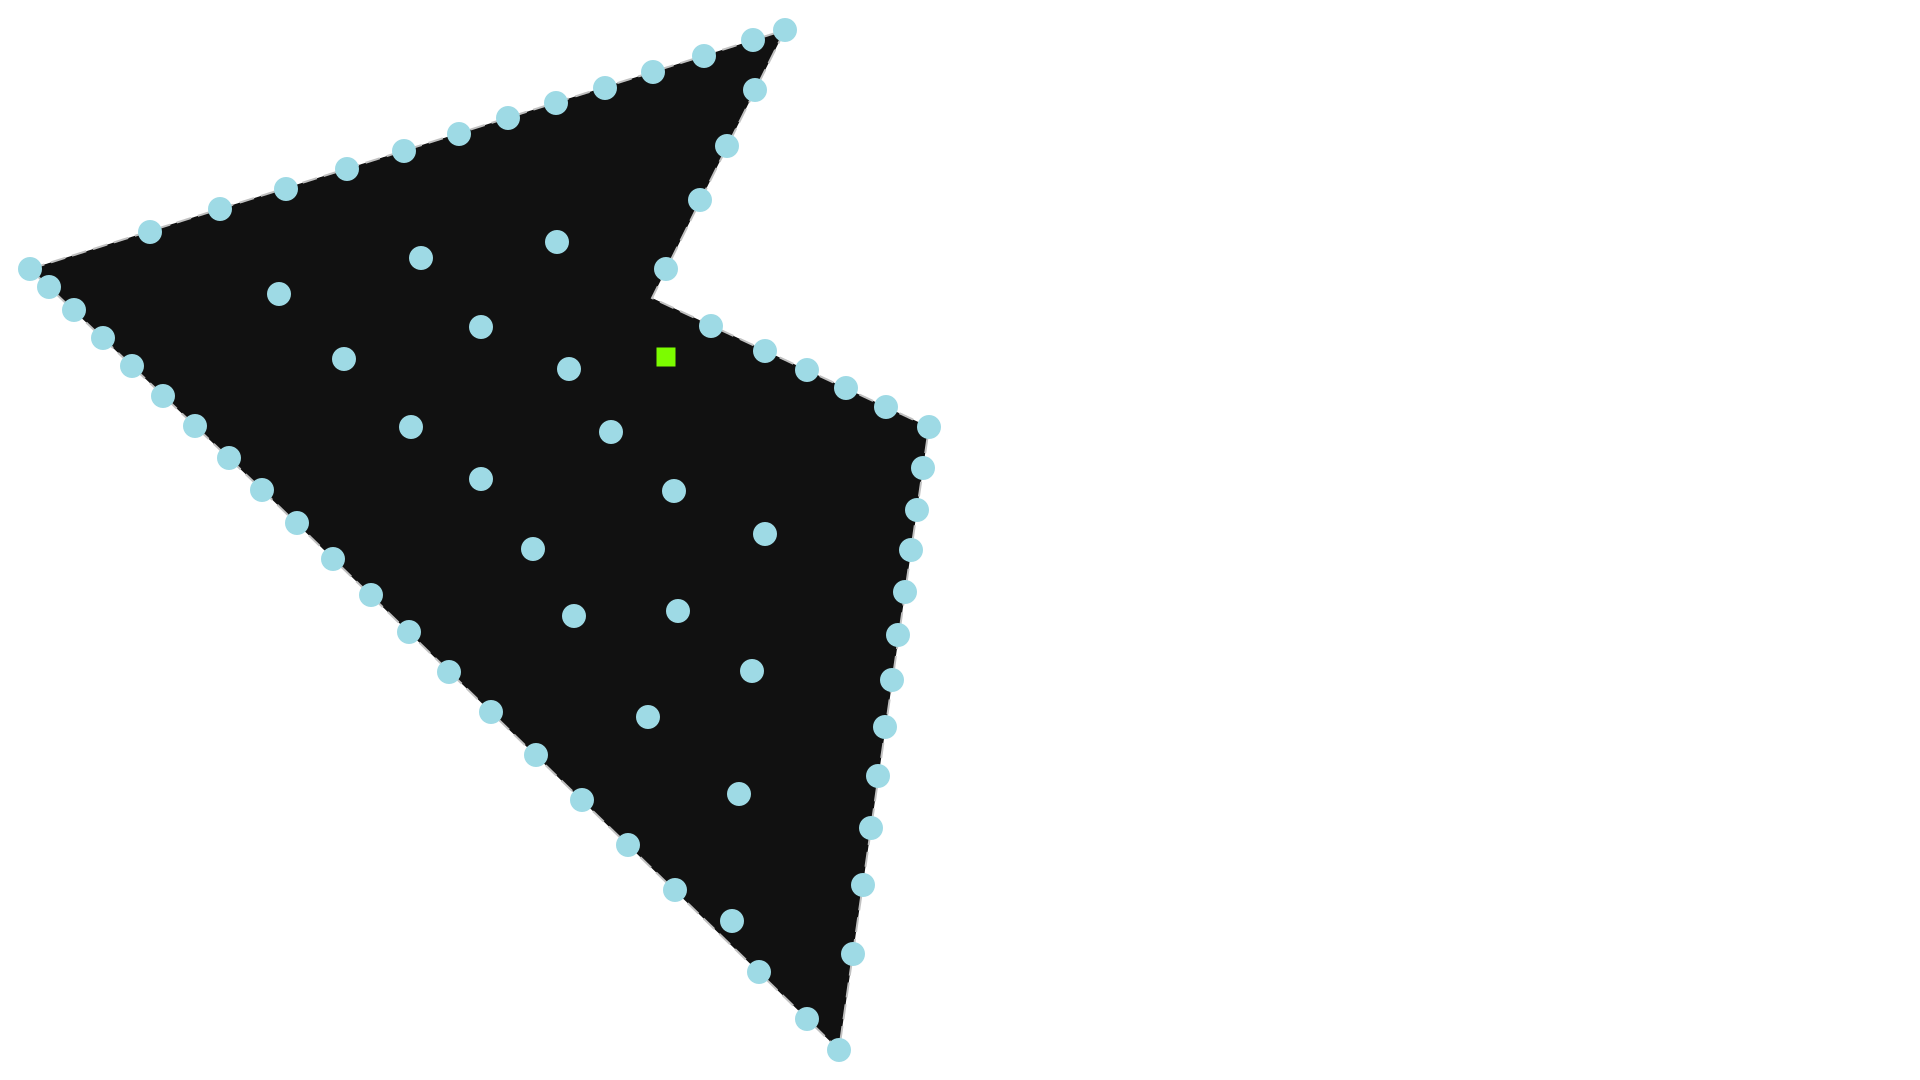

In [8]:
svgplot(L_irr)

### Additional design parameters

In [9]:
cable_costs = [206, 287, 406]  # [€/m] Costs per distance for each cable type
turbines_per_cable = [3, 5, 7]

In [10]:
cables = [(capacity, cost) for capacity, cost in zip(turbines_per_cable, cable_costs)]
capacity = max(turbines_per_cable)

### Choose the OR-Tools CP-Sat solver

In [11]:
solver = solver_factory('ortools.cp_sat')

### Regular layout

In [12]:
P, A = make_planar_embedding(L_reg)

In [13]:
# This meta-heuristic call is iterative and the time_limit applies
# to each iteration. About 97% of instances use a single iteration.
S_warm = hgs_cvrp(as_normalized(A), capacity=capacity, time_limit=1, seed=1234567)

Check the total length of the warm-start solution:

In [14]:
G_reg_warm = G_from_S(S_warm, A)
G_reg_warm.size(weight='length')

139656.4789599965

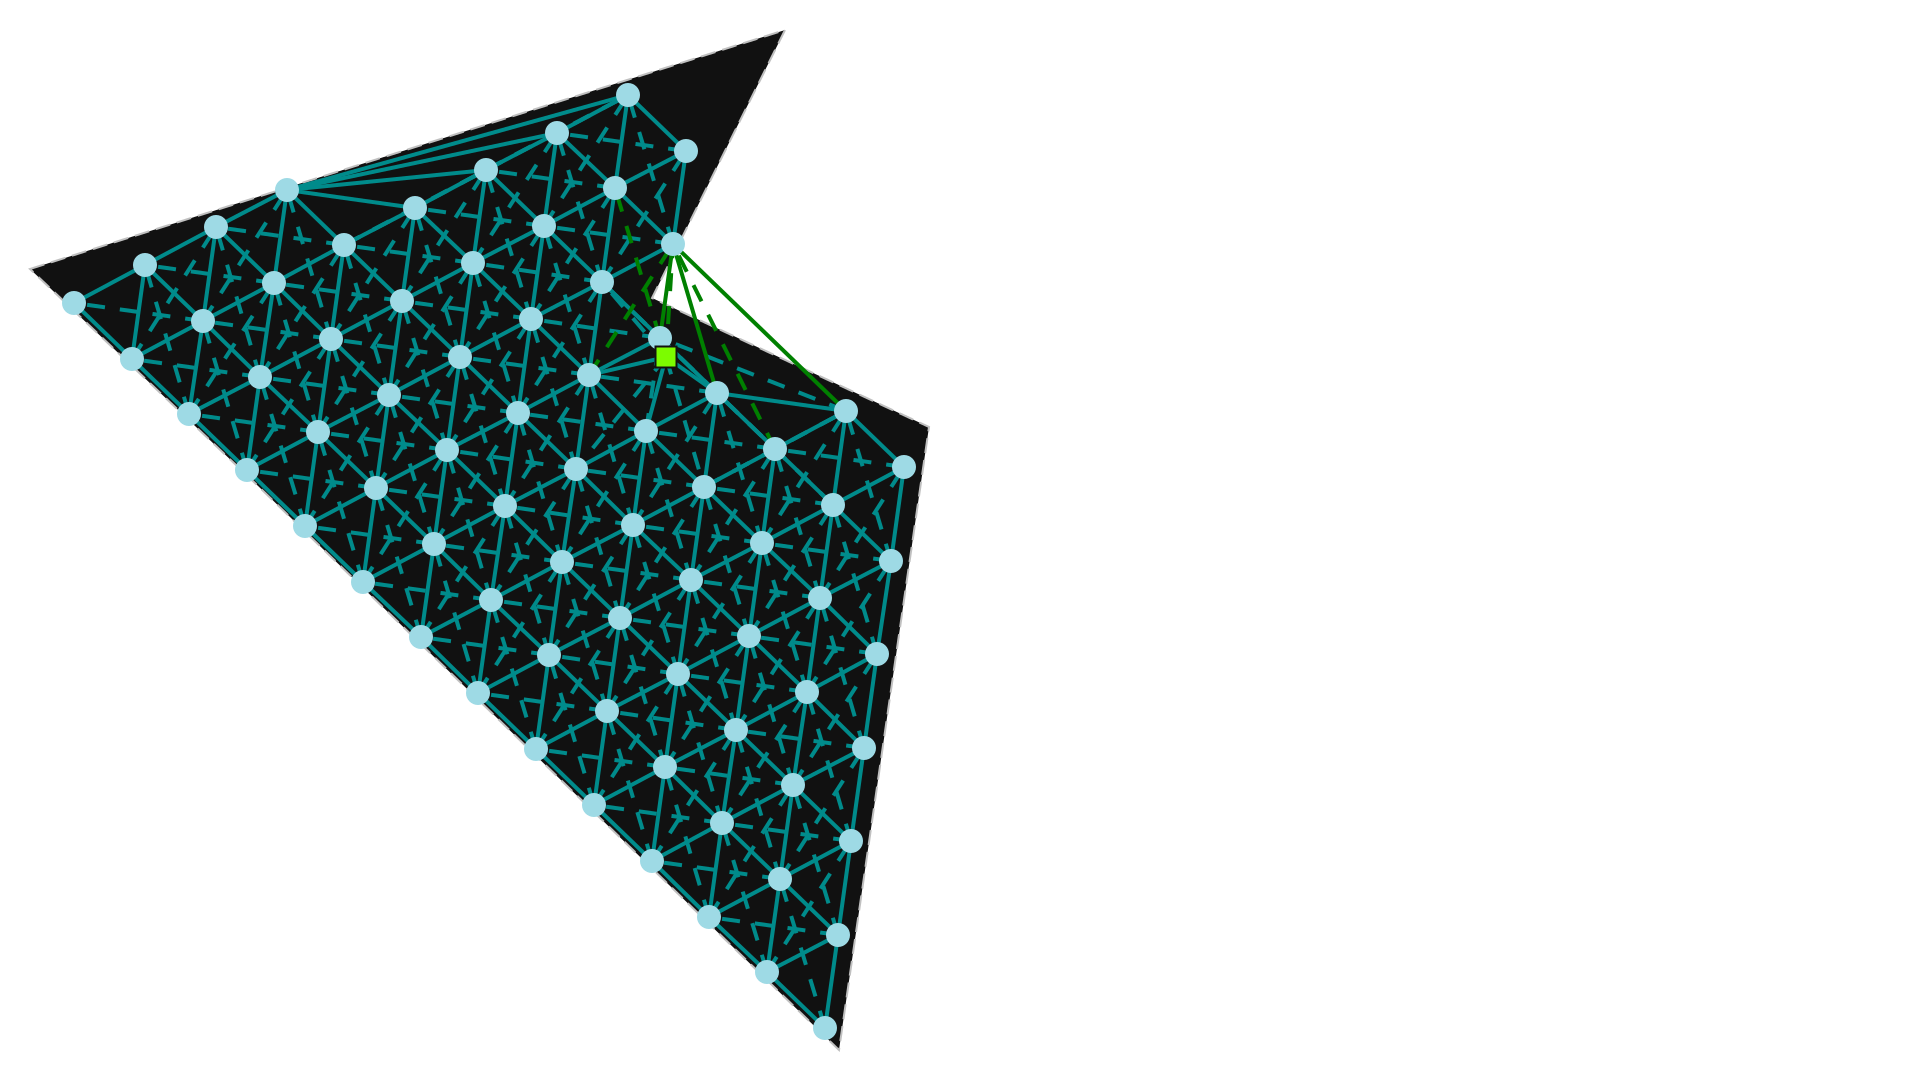

In [15]:
svgplot(A)

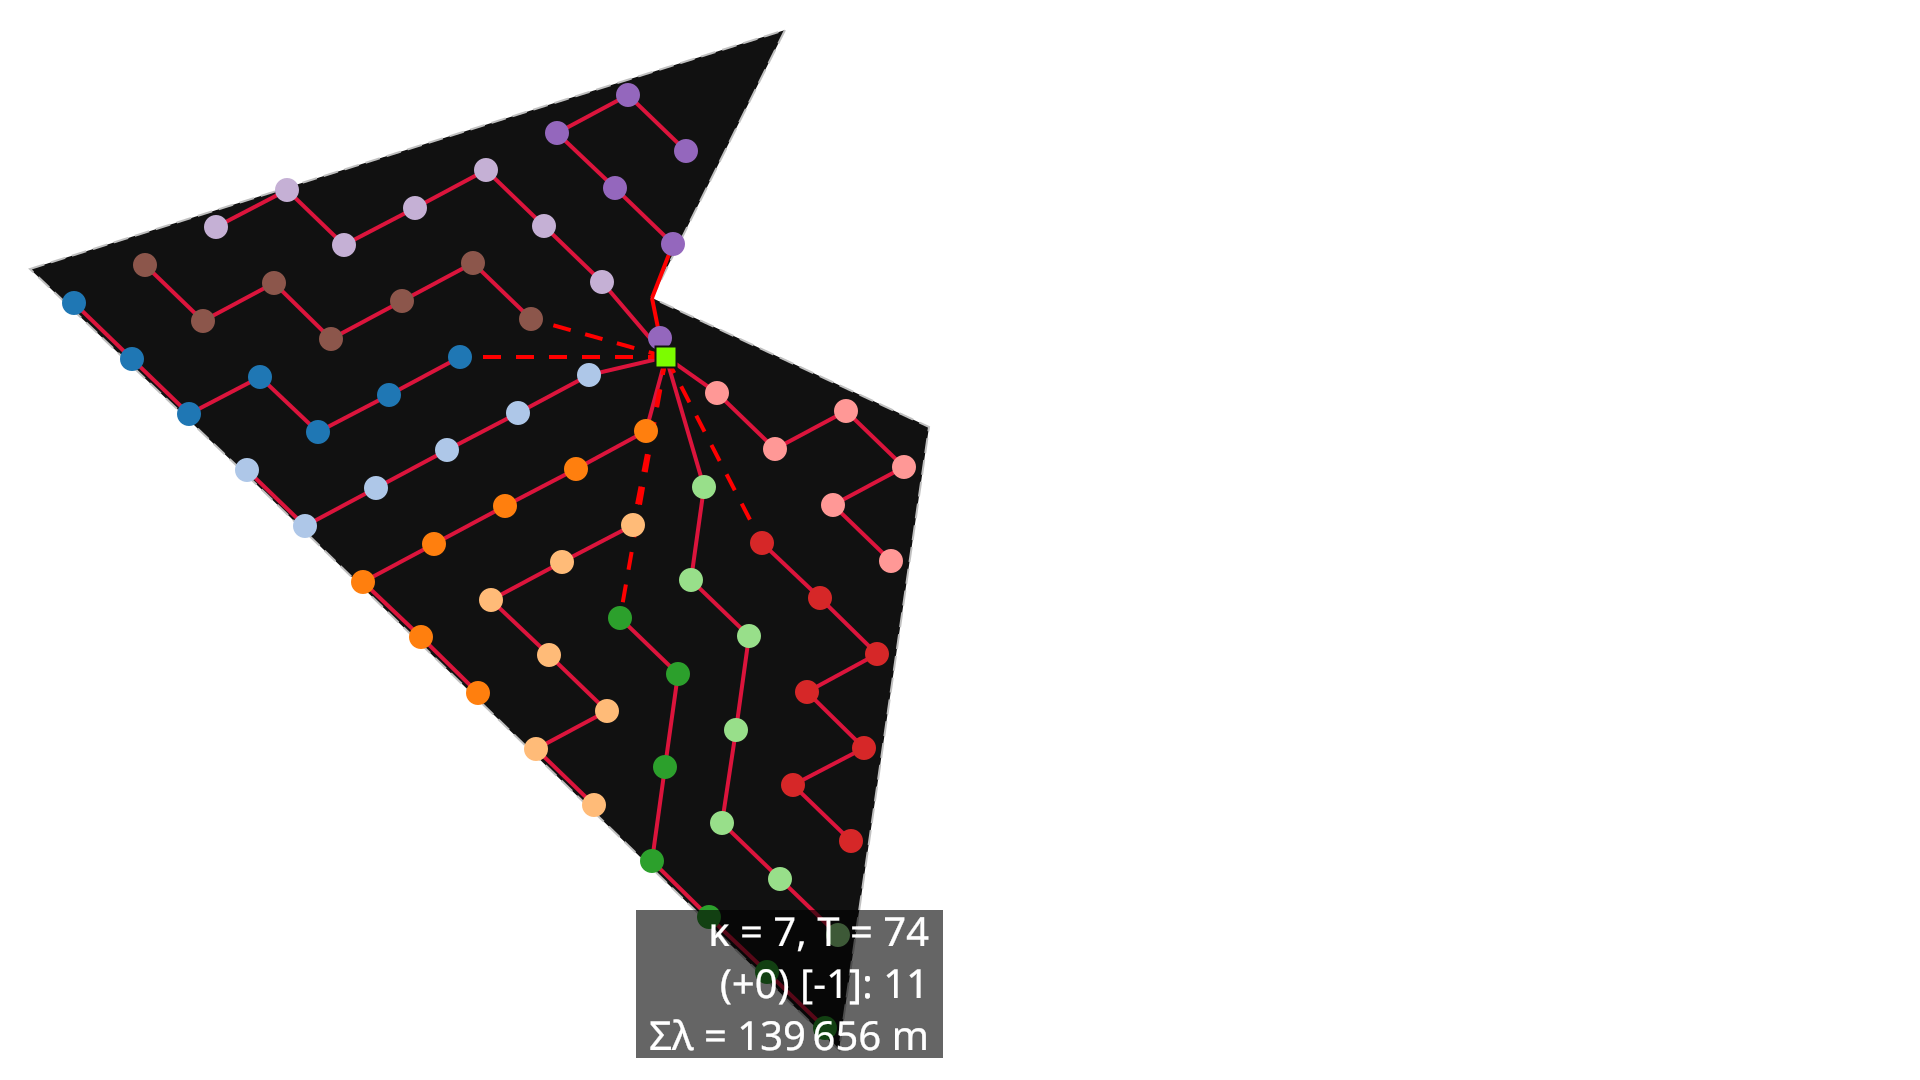

In [16]:
svgplot(G_reg_warm)

In [17]:
solver.set_problem(
    P,
    A,
    capacity=G_reg_warm.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=S_warm,
)

In [18]:
solver.solve(
    mip_gap=0.005,
    time_limit=5,
    options={'random_seed': 1234567},
)

SolutionInfo(
    termination = 'FEASIBLE'
    objective   = 139645.18
    bound       = 136681.73
    relgap      = 2.12%
    runtime     = 5.027s
    topology_id = 'fdde3ab5c4821e68c72c1b825cad181a'
)

In [19]:
S_reg, G_reg = solver.get_solution()

In [20]:
assign_cables(G_reg, cables)
G_reg.size(weight='cost')

40714260.58298516

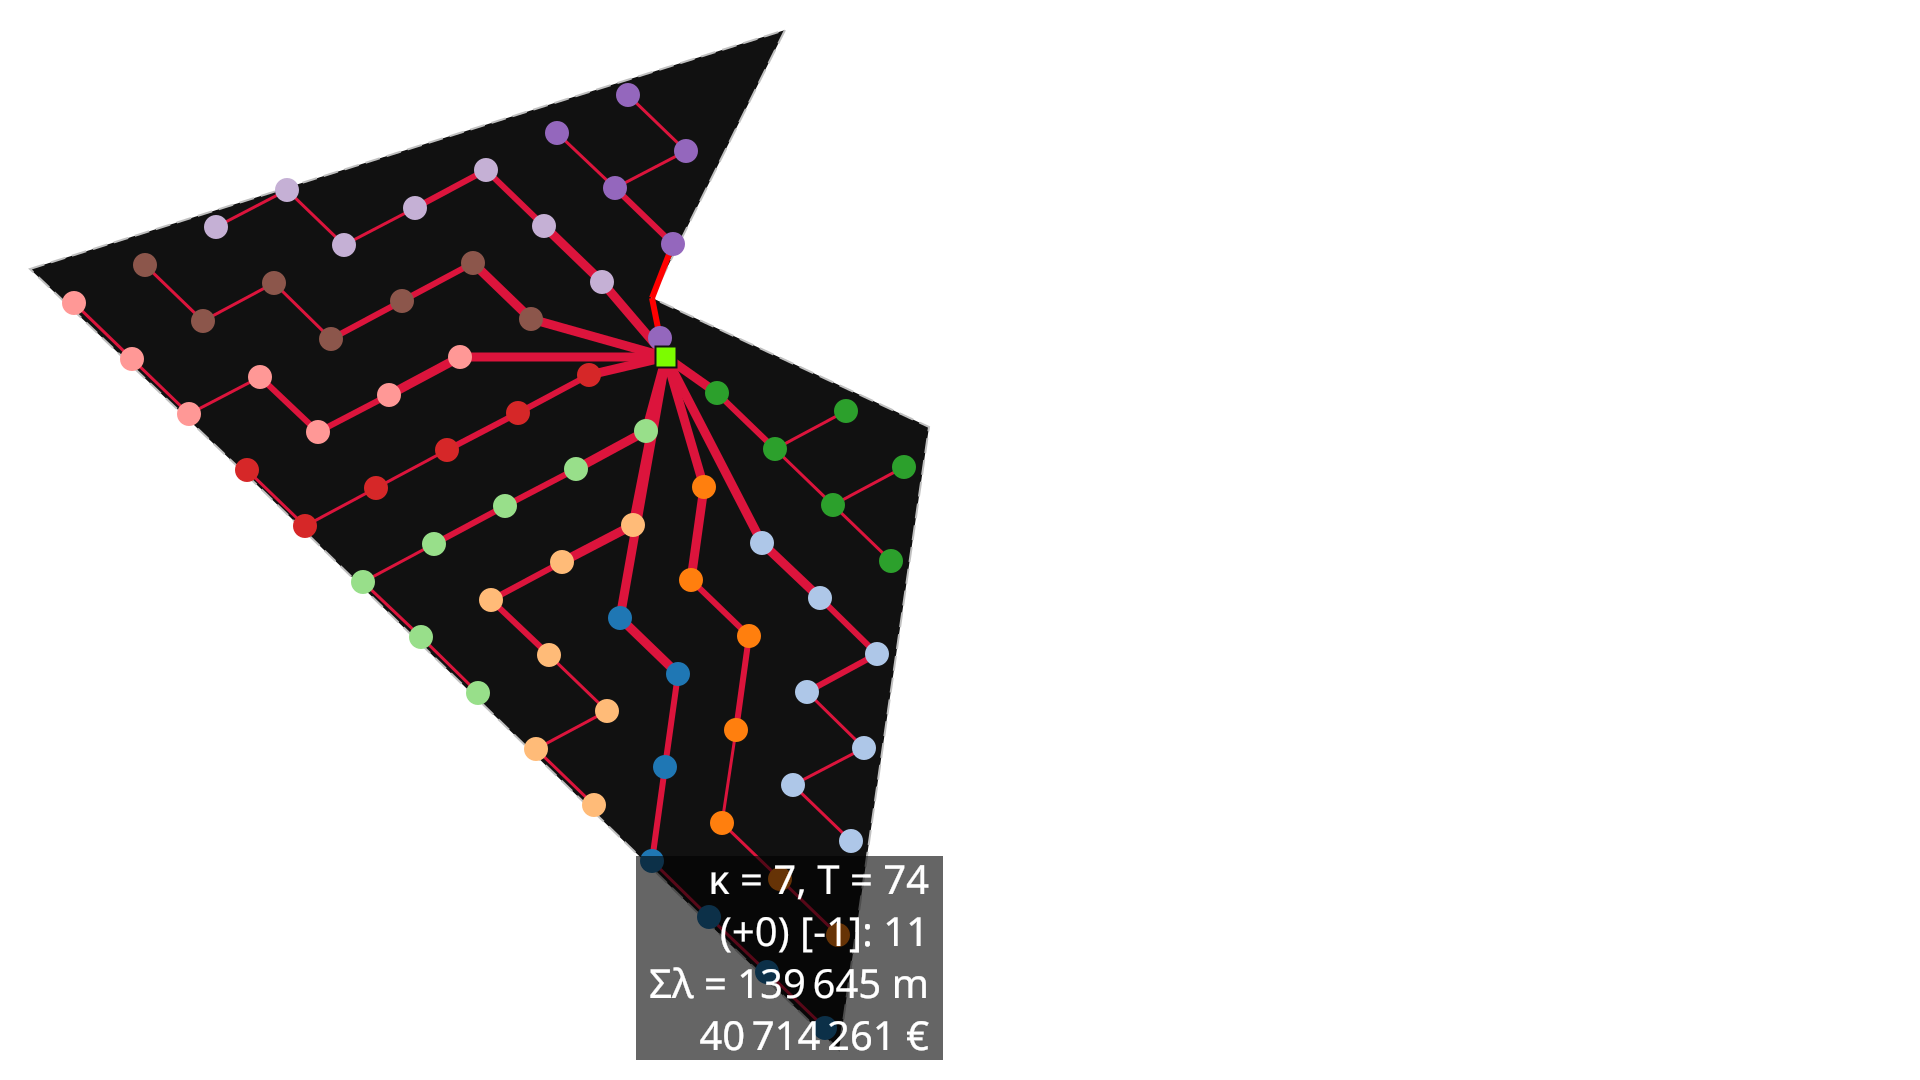

In [21]:
svgplot(G_reg)

### Irregular layout

In [22]:
P, A = make_planar_embedding(L_irr)

In [23]:
# This meta-heuristic call is iterative and the time_limit applies
# to each iteration. About 97% of instances use a single iteration.
S_warm = hgs_cvrp(as_normalized(A), capacity=capacity, time_limit=3, seed=1234567)

Check the total length of the warm-start solution:

In [24]:
G_irr_warm = G_from_S(S_warm, A)
G_irr_warm.size(weight='length')

136451.2768186806

In [25]:
solver.set_problem(
    P,
    A,
    capacity=G_irr_warm.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=S_warm,
)

In [26]:
solver.solve(
    mip_gap=0.005,
    time_limit=300,
    options={'random_seed': 1234567},
)

SolutionInfo(
    termination = 'FEASIBLE'
    objective   = 134786.79
    bound       = 132453.66
    relgap      = 1.73%
    runtime     = 300.1s
    topology_id = 'f3d4104a8608b5ea7df4380892f15c09'
)

In [27]:
S_irr, G_irr = solver.get_solution()

In [28]:
assign_cables(G_irr, cables)
G_irr.size(weight='cost')

43091183.191651106

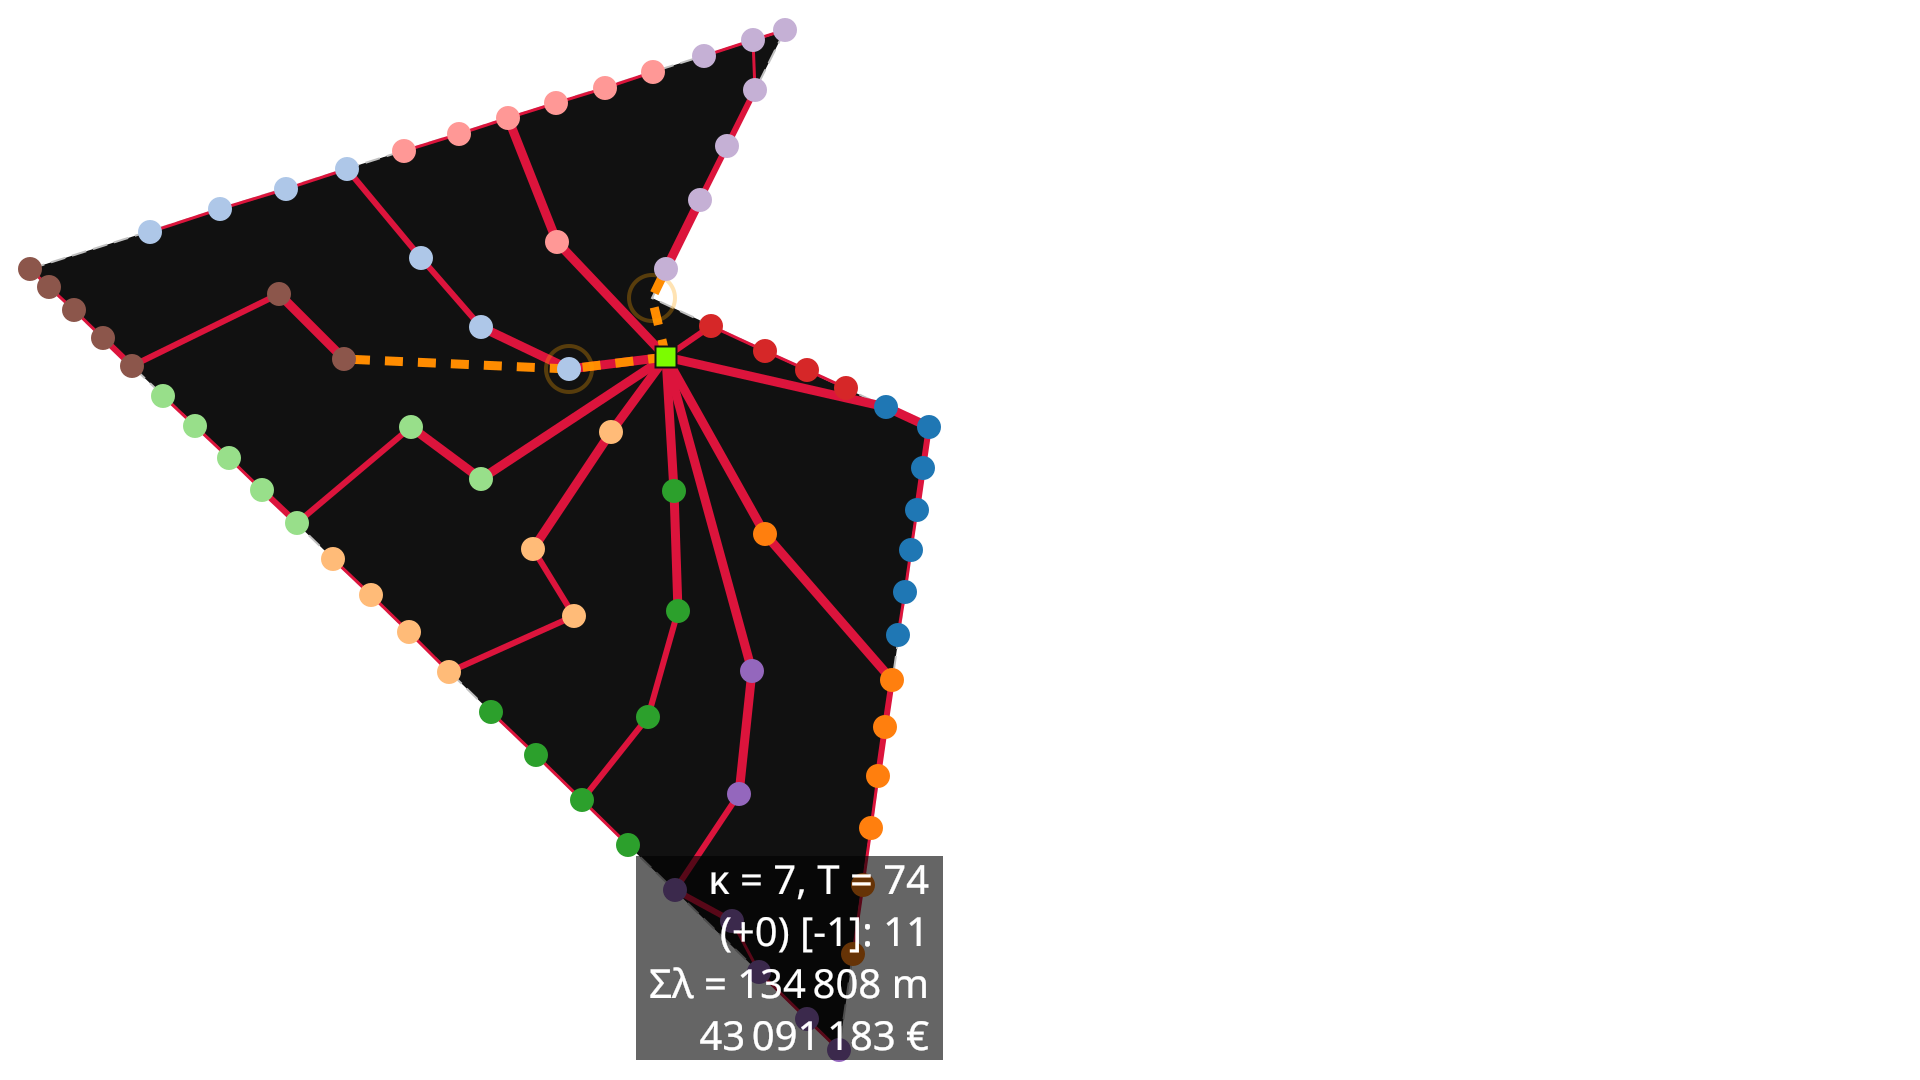

In [29]:
svgplot(G_irr)

### Layouts' edge list

These lists of 3-tuples have all the edges and their cable type (as an index to the `turbines_per_cable` list), i.e. (coordinate_A, coordinate_B, cable_type).

Negative node indices represent substations, the node indices ranging from 0 to 73 represent the WT in the order they were given.

If the layout has contours or detours, indices will go beyond the number of coordinates (WT, SS, borders) provided, and the mapping of these additional indices to indices to the provided coordinates is presented.

In [30]:
G_reg.edges(data='cable')

EdgeDataView([(-1, 47, 2), (-1, 56, 2), (-1, 46, 2), (-1, 33, 2), (-1, 45, 2), (-1, 57, 2), (-1, 34, 2), (-1, 24, 2), (-1, 49, 2), (-1, 58, 2), (-1, 32, 2), (0, 1, 0), (1, 4, 0), (2, 3, 0), (3, 8, 0), (4, 5, 0), (5, 9, 1), (6, 7, 0), (7, 12, 0), (8, 14, 0), (9, 15, 1), (10, 11, 0), (11, 16, 0), (12, 13, 0), (13, 20, 1), (14, 22, 1), (15, 24, 2), (16, 17, 0), (17, 26, 1), (18, 19, 0), (19, 28, 0), (20, 21, 1), (21, 32, 2), (22, 23, 1), (23, 33, 2), (25, 26, 1), (25, 34, 2), (27, 28, 0), (27, 36, 1), (29, 38, 0), (29, 40, 0), (30, 31, 0), (31, 44, 0), (31, 42, 0), (35, 36, 1), (35, 46, 2), (37, 48, 1), (37, 38, 0), (39, 50, 1), (39, 52, 1), (41, 52, 0), (41, 54, 0), (43, 44, 0), (44, 45, 1), (47, 48, 1), (49, 50, 2), (51, 62, 0), (51, 60, 1), (53, 62, 0), (53, 64, 0), (54, 55, 0), (56, 80, 1), (57, 67, 2), (58, 59, 2), (59, 60, 1), (61, 70, 0), (61, 69, 0), (63, 70, 0), (65, 80, 1), (65, 66, 1), (66, 71, 0), (66, 73, 0), (67, 68, 1), (68, 69, 1), (71, 72, 0)])

Mapping of contour/detour nodes to the index of their VertexC coordinate:

In [31]:
if G_reg.graph.get('C') or G_reg.graph.get('D'):
    R, T, B = (G_reg.graph[k] for k in 'RTB')
    print(
        dict(enumerate((n.item() for n in G_reg.graph['fnT'][T + B : -R]), start=T + B))
    )

{80: 76}


In [32]:
G_irr.edges(data='cable')

EdgeDataView([(-1, 41, 2), (-1, 28, 2), (-1, 49, 2), (-1, 55, 1), (-1, 39, 2), (-1, 60, 2), (-1, 70, 2), (-1, 25, 2), (-1, 33, 2), (-1, 80, 2), (-1, 81, 2), (0, 50, 0), (1, 34, 0), (2, 8, 1), (2, 7, 0), (3, 12, 1), (3, 15, 0), (4, 20, 0), (5, 9, 0), (5, 32, 0), (6, 35, 0), (7, 43, 0), (8, 42, 1), (9, 19, 0), (10, 24, 0), (11, 18, 0), (12, 45, 1), (13, 26, 0), (14, 68, 1), (14, 32, 1), (15, 21, 0), (16, 29, 1), (16, 17, 0), (17, 24, 0), (18, 59, 0), (20, 37, 1), (20, 34, 0), (21, 66, 0), (22, 44, 1), (22, 67, 1), (23, 43, 0), (25, 42, 2), (26, 31, 0), (27, 52, 0), (27, 38, 0), (28, 53, 2), (29, 53, 1), (30, 54, 1), (30, 56, 1), (31, 56, 0), (33, 45, 2), (35, 36, 0), (36, 62, 0), (37, 51, 1), (39, 63, 2), (40, 55, 0), (40, 57, 0), (41, 51, 2), (44, 46, 0), (46, 50, 0), (47, 65, 0), (48, 65, 0), (49, 54, 2), (52, 59, 0), (57, 72, 0), (58, 65, 0), (58, 61, 1), (59, 60, 2), (61, 64, 1), (62, 69, 1), (63, 69, 1), (64, 71, 2), (67, 70, 2), (68, 73, 2), (71, 81, 2), (73, 80, 2)])

Mapping of contour/detour nodes to the index of their VertexC coordinate:

In [33]:
if G_irr.graph.get('C') or G_irr.graph.get('D'):
    R, T, B = (G_irr.graph[k] for k in 'RTB')
    print(
        dict(enumerate((n.item() for n in G_irr.graph['fnT'][T + B : -R]), start=T + B))
    )

{80: 28, 81: 76}
